In [193]:
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad
import yfinance as yf

In [194]:
def Ruin(lam, r0, z_gen, p, t=1001):
    Nt = np.random.poisson(lam*t)
    if Nt == 0:
        return [t, r0 + p(t)]
    Z = z_gen(size=Nt)
    T = np.random.uniform(high=t, size=Nt)
    T = np.sort(T)
    Z_sum = np.cumsum(Z)
    R = r0 + np.array([p(ti) for ti in T]) - Z_sum
    idx = np.argmax(R <= 0)
    if R[idx] <= 0:
        R = R[:idx]
        return [T[idx], R]
    return [t, R]

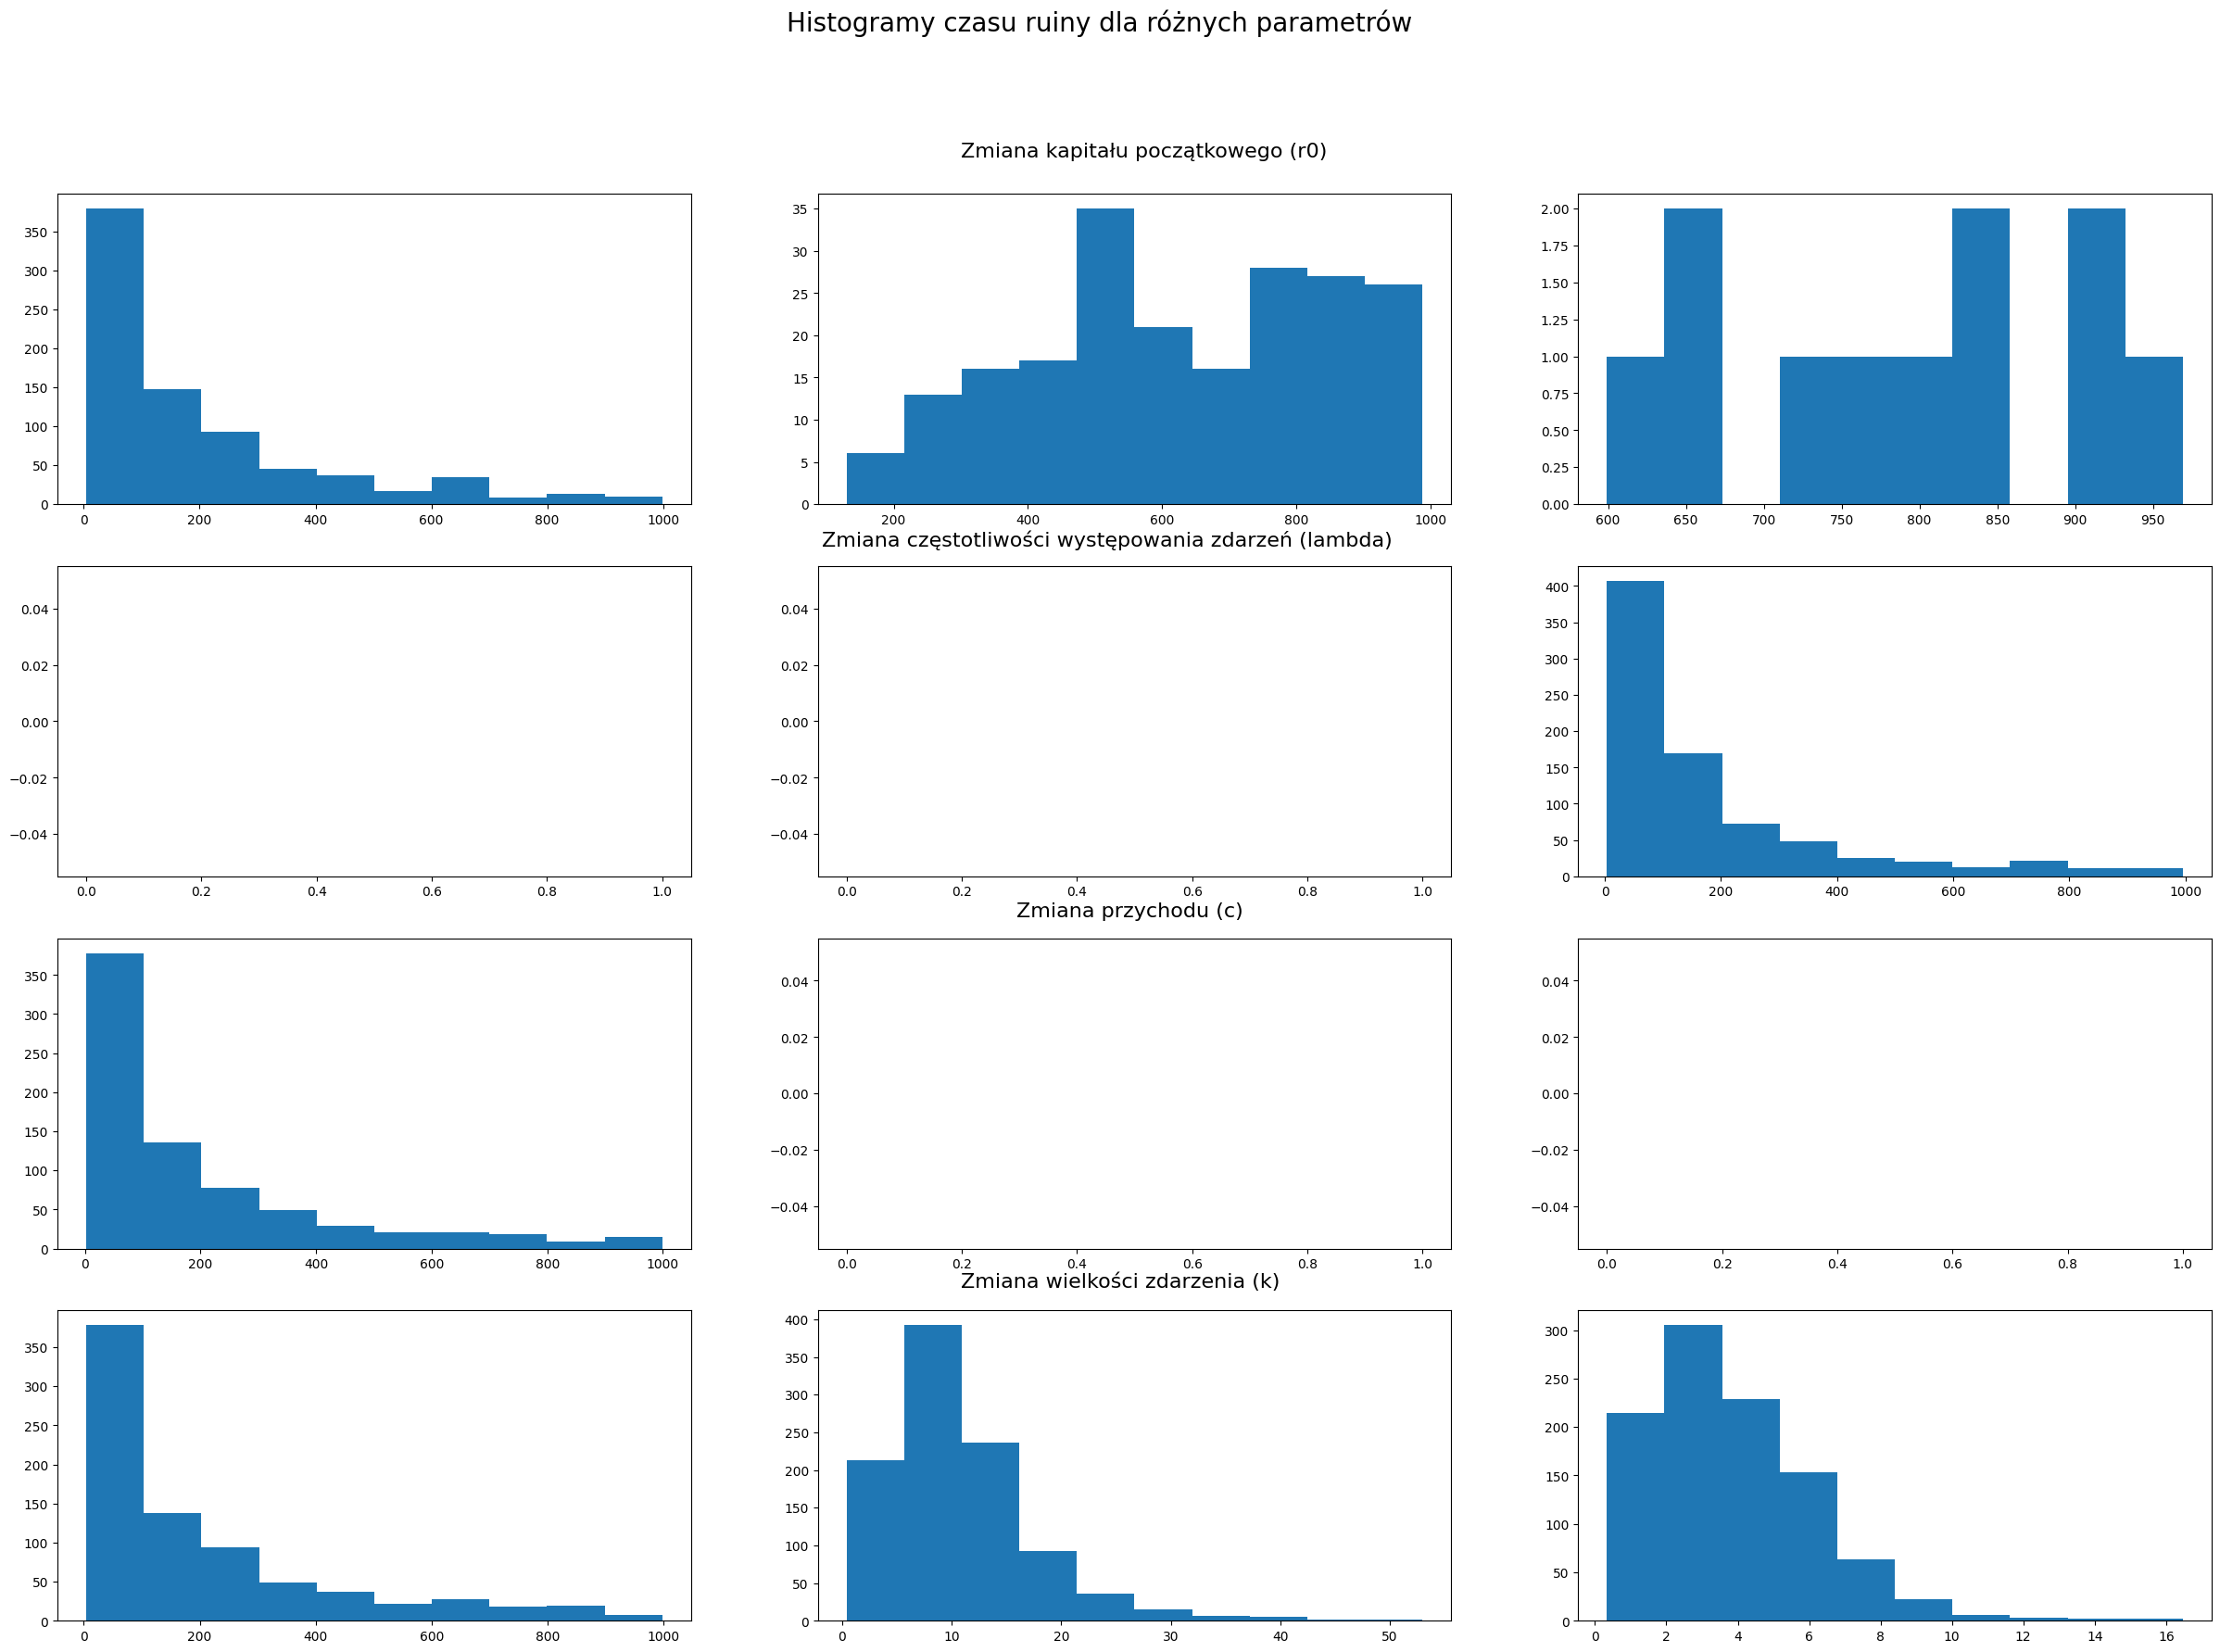

In [195]:
r0 = [10, 50, 100]
lam = [0.5, 1, 2]
c = [1, 2, 3]
k = [0.5, 1, 2]

Y_r = []
Y_lam = []
Y_c = []
Y_k = []

T = 1000

for i in range(3):
    y1 = [Ruin(lam=lam[2], r0=r0[i], z_gen=lambda size: np.random.poisson(lam=k[0], size=size), 
           p=lambda t: c[0] * t)[0] for _ in range(1000)]
    y2 = [Ruin(lam=lam[i], r0=r0[0], z_gen=lambda size: np.random.poisson(lam=k[0], size=size), 
           p=lambda t: c[0] * t)[0] for _ in range(1000)]
    y3 = [Ruin(lam=lam[2], r0=r0[0], z_gen=lambda size: np.random.poisson(lam=k[0], size=size), 
           p=lambda t: c[i] * t)[0] for _ in range(1000)]
    y4 = [Ruin(lam=lam[2], r0=r0[0], z_gen=lambda size: np.random.poisson(lam=k[i], size=size), 
           p=lambda t: c[0] * t)[0] for _ in range(1000)]
    
    y1 = [x for x in y1 if x < T + 1]
    y2 = [x for x in y2 if x < T + 1]
    y3 = [x for x in y3 if x < T + 1]
    y4 = [x for x in y4 if x < T + 1]

    Y_r.append(y1)
    Y_lam.append(y2)
    Y_c.append(y3)
    Y_k.append(y4)

fig, axs = plt.subplots(4, 3, figsize=(30,20))


for j in range(3):
    axs[0][j].hist(Y_r[j])
    axs[1][j].hist(Y_lam[j])
    axs[2][j].hist(Y_c[j])
    axs[3][j].hist(Y_k[j])

fig.suptitle('Histogramy czasu ruiny dla różnych parametrów', fontsize=20)
fig.text(0.45, 0.9, 'Zmiana kapitału początkowego (r0)', fontsize=16)
fig.text(0.40, 0.69, 'Zmiana częstotliwości występowania zdarzeń (lambda)', fontsize=16)
fig.text(0.47, 0.49, 'Zmiana przychodu (c)', fontsize=16)
fig.text(0.45, 0.29, 'Zmiana wielkości zdarzenia (k)', fontsize=16)
plt.show()

In [196]:
# Średnie i odchylenia standardowe czasu ruiny
import warnings
warnings.filterwarnings("ignore")

Y_fin = [Y_r, Y_lam, Y_c, Y_k]
text_list = ['r0', 'lambda', 'c', 'k']

for k in range(4):
    print(f'Zestawienie średniej i wariancji dla różnych parametrów {text_list[k]}: ')
    M = []
    V = []
    for i in range(3):
        M.append(np.round(np.mean(Y_fin[k][i]), 1))
        V.append(np.round(np.var(Y_fin[k][i]), 1))
    print(f'Średnie: {M}')
    print(f'Wartość wariancji: {V}')

Zestawienie średniej i wariancji dla różnych parametrów r0: 
Średnie: [193.4, 627.5, 791.0]
Wartość wariancji: [44914.8, 51525.3, 13163.6]
Zestawienie średniej i wariancji dla różnych parametrów lambda: 
Średnie: [nan, nan, 178.5]
Wartość wariancji: [nan, nan, 43645.1]
Zestawienie średniej i wariancji dla różnych parametrów c: 
Średnie: [194.6, nan, nan]
Wartość wariancji: [49508.3, nan, nan]
Zestawienie średniej i wariancji dla różnych parametrów k: 
Średnie: [204.3, 10.7, 3.8]
Wartość wariancji: [49167.3, 44.1, 4.9]


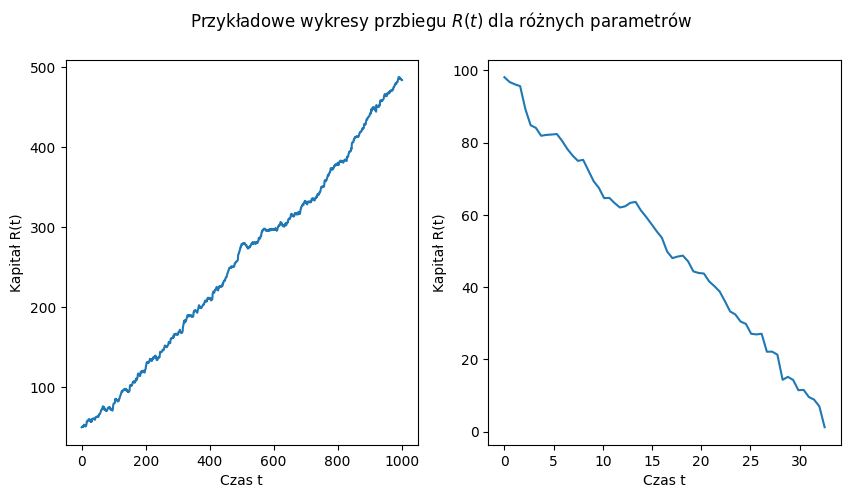

In [197]:
# Wykres przebiegu R(t)

y_R1 = Ruin(lam=lam[1], r0=r0[1], z_gen=lambda size: np.random.poisson(lam=0.5, size=size), 
           p=lambda t: t)
y_R2 = Ruin(lam=lam[2], r0=r0[2], z_gen=lambda size: np.random.poisson(lam=2, size=size), 
           p=lambda t: t)
t_R1 = np.linspace(0, y_R1[0], len(y_R1[1]))
t_R2 = np.linspace(0, y_R2[0], len(y_R2[1]))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(t_R1, y_R1[1])
ax[1].plot(t_R2, y_R2[1])

fig.suptitle('Przykładowe wykresy przbiegu $R(t)$ dla różnych parametrów')
for i in range(2):
    ax[i].set_xlabel('Czas t')
    ax[i].set_ylabel('Kapitał R(t)')
plt.show()

### Zadanie 4 (opcjonalne)

### Zadanie 5
Mieszany proces Poissona

In [198]:
def mix_Poiss(T, f_gen):
    lam = f_gen()
    n = np.random.poisson(lam*T)
    U = np.random.uniform(0, T, size=n)
    U = np.sort(U)
    return U

def Nt(S, t):
    S = np.array(S)
    return np.sum(S <= t)

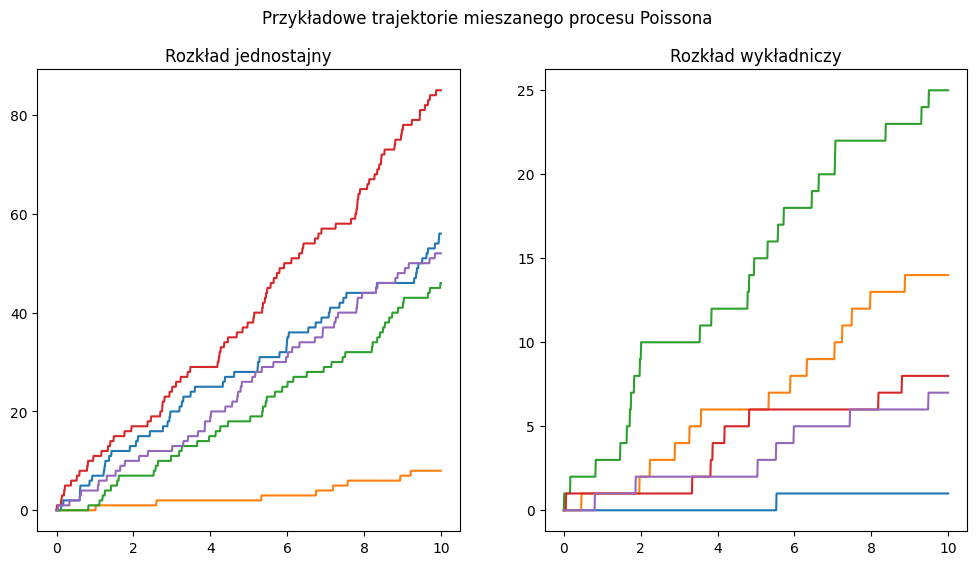

In [ ]:
T = 10
uniform_poiss = [mix_Poiss(T, lambda: np.random.uniform(0, 10)) for _ in range(5)]

exp_poiss = [mix_Poiss(T, lambda: np.random.exponential(1)) for _ in range(5)]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for y in uniform_poiss:
    t = np.linspace(0, T, 1000)
    N_t = [Nt(y, ti) for ti in t]
    axs[0].plot(t, N_t)

for y in exp_poiss:
    t = np.linspace(0, T, 1000)
    N_t = [Nt(y, ti) for ti in t]
    axs[1].plot(t, N_t)

fig.suptitle('Przykładowe trajektorie mieszanego procesu Poissona')
axs[0].set_title('Rozkład jednostajny')
axs[1].set_title('Rozkład wykładniczy')
plt.show()

### Zadanie 6

Mieszany proces Poissona dla różnych rozkładów L

P(N(t) = k) = $\int_{0}^{\infty} e^{-\lambda t}\frac{(\lambda t)^k}{k!} f_L(\lambda)\, d\lambda$

Ważne, dla L $\in [-\infty, 0)$, f_L = 0

In [200]:
def poisson_mix_pmf(f_L, k, t, bounds = [0, np.inf]):
    if k < 0: return 0
    poiss = lambda lam: sc.poisson.pmf(k, lam*t) * f_L(lam)
    integral = quad(poiss, a=bounds[0], b=bounds[1])
    return integral[0]

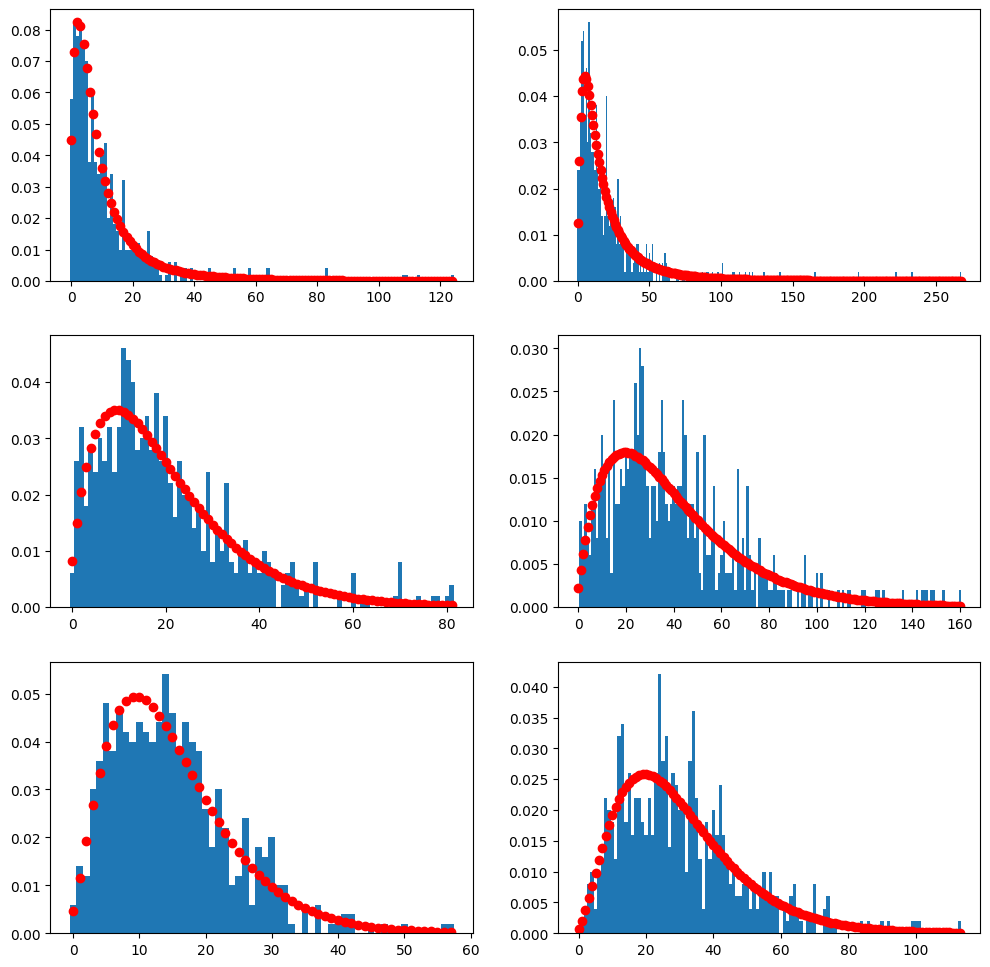

In [201]:
T = 5
N = 500
P1 = [mix_Poiss(T, lambda: np.random.lognormal(1)) for _ in range(N)]
P2 = [mix_Poiss(T, lambda: np.random.gamma(2, 4)) for _ in range(N)]
P3 = [mix_Poiss(T, lambda: np.random.chisquare(6)) for _ in range(N)]
P = [P1, P2, P3]

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
f_list = [lambda x: sc.lognorm.pdf(x, s=1, scale=np.exp(1)), 
          lambda x: sc.gamma.pdf(x, 2, scale=4), 
          lambda x: sc.chi2.pdf(x, 6)]
for i in range(3):
    N_1 = [Nt(P[i][idx], T/2) for idx in range(N)]
    N_2 = [Nt(P[i][idx], T) for idx in range(N)]

    b1 = np.max(N_1)
    b2 = np.max(N_2)
    k1 = np.arange(0, b1 + 1, 1)
    k2 = np.arange(0, b2 + 1, 1)

    y1 = [poisson_mix_pmf(f_list[i], ki, T/2) for ki in k1]
    y2 = [poisson_mix_pmf(f_list[i], ki, T) for ki in k2]

    axs[i][0].hist(N_1, bins=np.arange(b1 + 2) - 0.5, density=True)
    axs[i][0].plot(k1, y1, 'ro')
    axs[i][1].hist(N_2, bins=np.arange(b2 + 2) - 0.5, density=True)
    axs[i][1].plot(k2, y2, 'ro')

### Zadanie 7 - Ruch Browna i procesy Levyego

In [202]:
def Brown_traj(T, n):
    dt = T/(n-1)
    dB = np.sqrt(dt) * np.random.normal(size=n-1)
    B = np.concatenate(([0], np.cumsum(dB)))
    return B

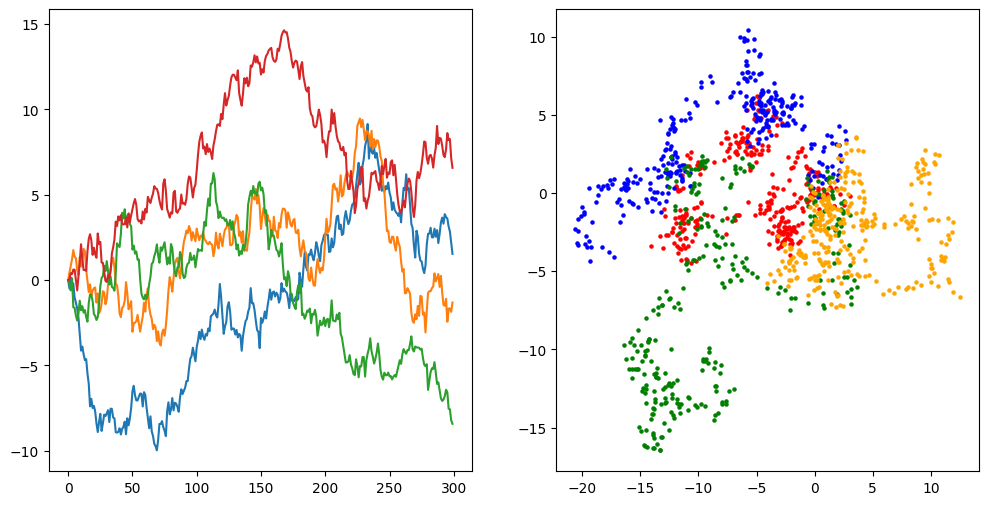

In [203]:
T = 100
n = 300
N = 4

Brown_1d = [Brown_traj(T, n) for _ in range(N)]
Brown_2dx = [Brown_traj(T, n) for _ in range(N)]
Brown_2dy = [Brown_traj(T, n) for _ in range(N)]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

colors = ['red', 'blue', 'green', 'orange']

for k in range(N):
    axs[0].plot(Brown_1d[k])
    axs[1].scatter(Brown_2dx[k], Brown_2dy[k], color=colors[k], s=5)
plt.show()


### Zadanie 8 - Wariancja ruchu Browna


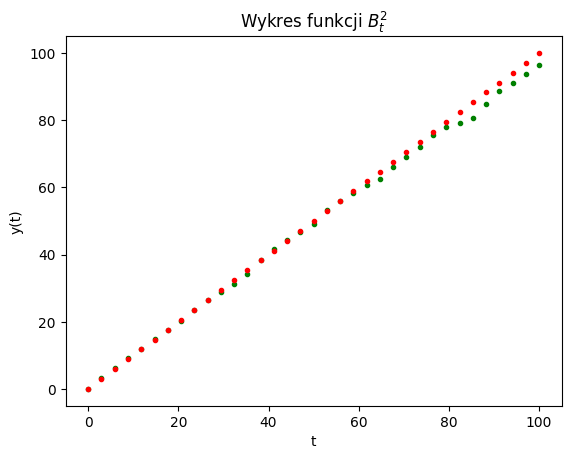

In [204]:
T = 100
n = 35
y_B = [Brown_traj(T=T, n=n) for _ in range(1000)]
Bt2 = [y**2 for y in y_B]

E_B = np.mean(Bt2, axis=0)
x_B = np.linspace(0, T, n)
plt.plot(x_B, E_B, 'go', markersize=3)
plt.title(f'Wykres funkcji $B^2_t$')
plt.plot(x_B, x_B, 'ro', markersize=3)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()

### Zadanie 9 - Most Browna

In [205]:
def Brown_bridge(T, n):
    t = np.linspace(0, T, n)
    B = Brown_traj(T, n)
    return B - t/T * B[n-1]

def func(t, T):
    return t*(T - t)/T

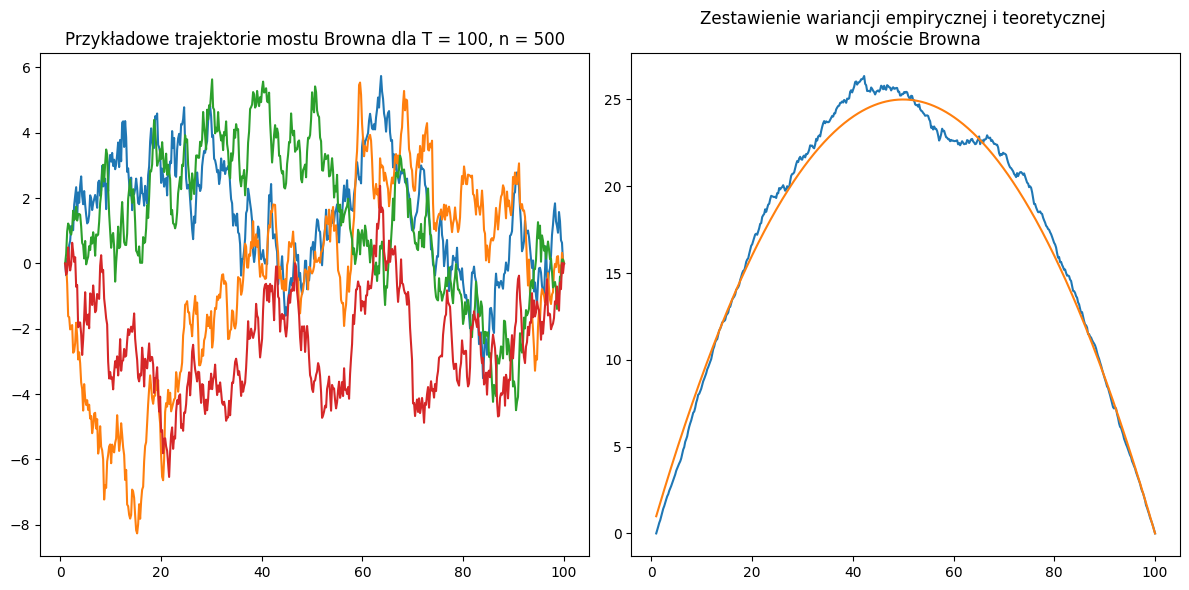

In [206]:
T = 100
n = 500
B_bridge = [Brown_bridge(T, n) for _ in range(1000)]
x_bridge = np.linspace(1, T, n)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for b in range(4):
    axs[0].plot(x_bridge, B_bridge[b])
axs[0].set_title(f'Przykładowe trajektorie mostu Browna dla T = 100, n = 500')

var_bridge = np.var(B_bridge, axis=0)

axs[1].plot(x_bridge, var_bridge)
axs[1].plot(x_bridge, func(x_bridge, T))
axs[1].set_title(f'Zestawienie wariancji empirycznej i teoretycznej \n w moście Browna')
plt.tight_layout()
plt.show()

### Zadanie 10 - Procesy Levyego

In [207]:
def levy_gamma(lam, beta, n, T):
    dt = T/n
    gamma = np.random.gamma(shape=lam*dt, scale=beta, size=n)
    return np.cumsum(gamma)

def levy_variance_gamma(lam, beta, n, T):
    g1 = levy_gamma(lam, beta, n, T)
    g2 = levy_gamma(lam, beta, n, T)
    return g1 - g2

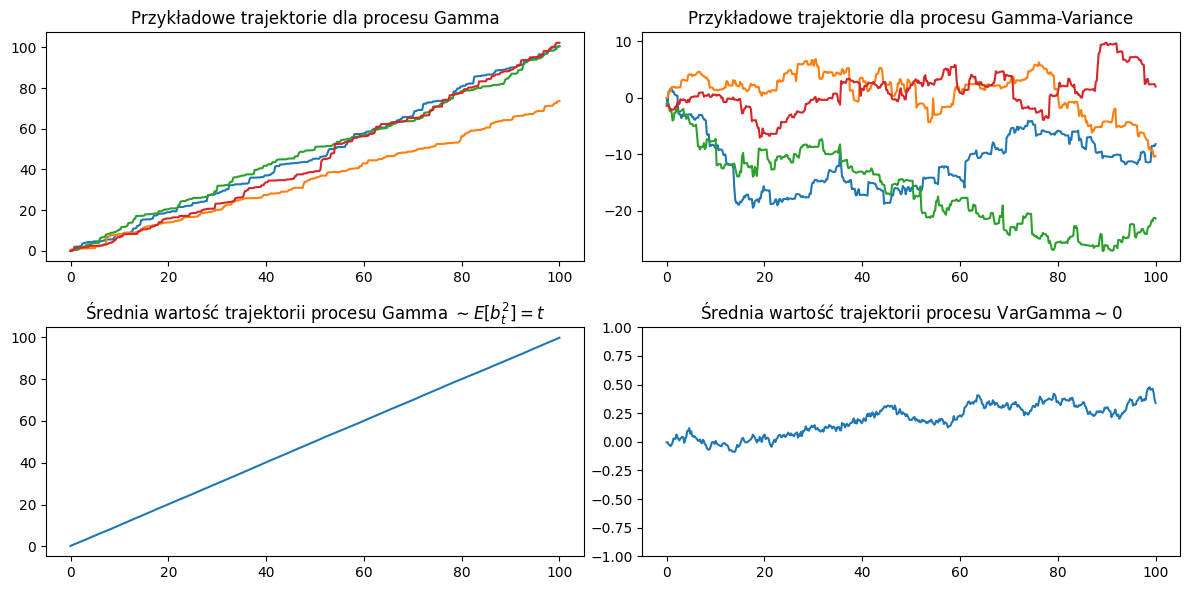

In [208]:
n = 500
T = 100
gamma_process = [levy_gamma(lam=1, beta=1, n=n, T=T) for _ in range(1000)]
gamma_var_process = [levy_variance_gamma(lam=1, beta=1, n=n, T=T) for _ in range(1000)]
x_gamma = np.linspace(0, T, n)

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
for k in range(4):
    axs[0][0].plot(x_gamma, gamma_process[k])
    axs[0][1].plot(x_gamma, gamma_var_process[k])

axs[0][0].set_title('Przykładowe trajektorie dla procesu Gamma')
axs[0][1].set_title('Przykładowe trajektorie dla procesu Gamma-Variance')

gamma_mean = np.mean(gamma_process, axis=0)
gamma_var_mean = np.mean(gamma_var_process, axis=0)

axs[1][0].plot(x_gamma, gamma_mean)
axs[1][1].plot(x_gamma, gamma_var_mean)
axs[1][0].set_title(f'Średnia wartość trajektorii procesu Gamma $ \sim E[b^2_t] = t$')
axs[1][1].set_title(f'Średnia wartość trajektorii procesu VarGamma$\sim 0$')
axs[1][1].set_ylim(-1, 1)
plt.tight_layout()
plt.show()

### Geometryczny ruch Browna


In [209]:
def Brown_geo(S0, mu, sigma, T, N):
    dt = T/N
    B = np.random.normal(0, np.sqrt(dt), size=N)
    B_cum = np.cumsum(B)
    t = np.linspace(0, T, N)
    S = S0 * np.exp(( mu- 0.5 * sigma**2) * t + sigma*B_cum)
    return S

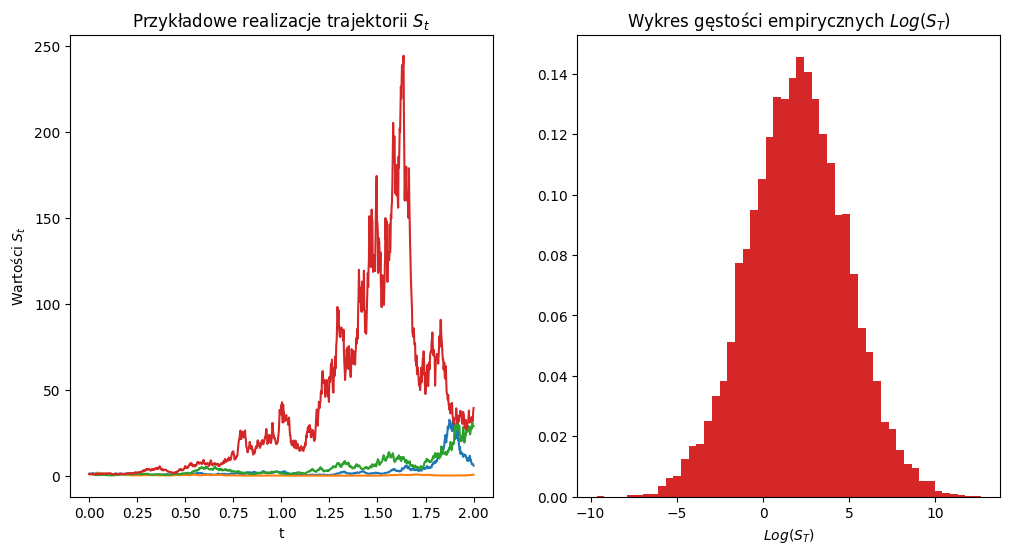

In [210]:
N = 1000
T = 2
B_geom = np.array([Brown_geo(1, 3, 2, T, N) for _ in range(10000)])
x_brown = np.linspace(0, T, N)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for k in range(4):
    axs[0].plot(x_brown, B_geom[k])
    axs[0].set_title('Przykładowe realizacje trajektorii $S_t$')
    axs[0].set_ylabel('Wartości $S_t$')
    axs[0].set_xlabel('t')
    brown_last = B_geom[:, -1]
    axs[1].hist(np.log(brown_last), bins=50, density=True)

    axs[1].set_xlabel('$Log(S_T)$')
    axs[1].set_title('Wykres gęstości empirycznych $Log(S_T)$')

plt.show()

### Zadanie 12 - Szacowanie parametrów i symulacja ścieżek GBM dla danych giełdowych

In [211]:
from datetime import datetime

def stock_returns(stock, time_range, interval='1d'):
    S = stock.history(start=time_range[0], end=time_range[1], interval=interval)['Close'].to_numpy()
    S2 = S[1:]
    S1 = S[:-1]
    r_t = np.log(S2/S1)
    return [np.mean(r_t), np.var(r_t), S]

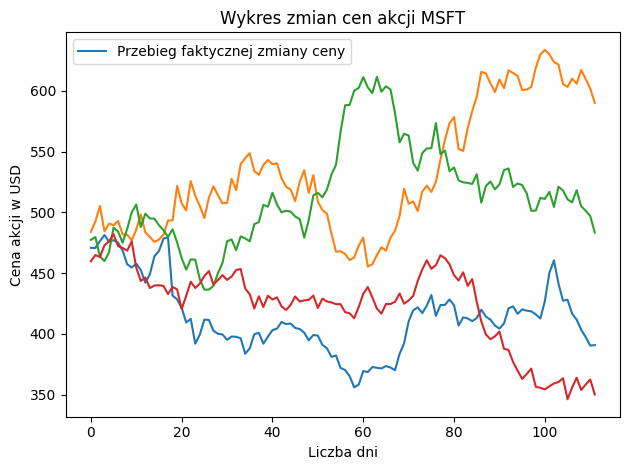

In [212]:
msft = yf.Ticker("MSFT")
period = ['2026-01-01', '2026-06-15']

EX, VarX, prices = stock_returns(msft, period,'1d')

start_price = prices[0]
Brown_simulation = [Brown_geo(S0=start_price, mu=EX, sigma = np.sqrt(VarX), T=len(prices), N=len(prices)) for _ in range(3)]
plt.plot(prices, label='Przebieg faktycznej zmiany ceny')
plt.title(f'Wykres zmian cen akcji MSFT')
plt.xlabel('Liczba dni')
plt.ylabel('Cena akcji w USD')

for brown in Brown_simulation:
    plt.plot(brown)

plt.legend()
plt.tight_layout()
plt.show()
